In [21]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import torch
import torchvision.models as models
import torchvision.transforms as T

# -----------------------------------
# CONFIGURATION
# -----------------------------------
KITTI_PATH = "/Users/mayuri/Downloads/dataset/sequences/00/image_0"
POSE_FILE = "/Users/mayuri/Downloads/dataset 2/poses/00.txt"
N_IMAGES = 300            # For demo
RESIZE_TO = (640, 192)
ORB_FEATURES = 1000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------------
# 1. Load KITTI images
# -----------------------------------
def load_images(path, n_images):
    files = sorted(os.listdir(path))[:n_images]
    images = []
    for f in files:
        img = cv2.imread(os.path.join(path, f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        images.append(gray)
    return images, files

In [22]:
# -----------------------------------
# 2. Preprocessing
# -----------------------------------
def preprocess_image(img):
    img_resized = cv2.resize(img, RESIZE_TO)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_eq = clahe.apply(img_resized)
    img_blur = cv2.GaussianBlur(img_eq, (3,3), 0)
    return img_blur

def preprocess_images(images):
    return [preprocess_image(img) for img in tqdm(images, desc="Preprocessing images")]

In [23]:
# -----------------------------------
# 3. ORB feature extraction
# -----------------------------------
def extract_orb_features(images):
    orb = cv2.ORB_create(nfeatures=ORB_FEATURES)
    descriptors = []
    keypoints = []
    for img in tqdm(images, desc="Extracting ORB features"):
        kp, des = orb.detectAndCompute(img, None)
        keypoints.append(kp)
        descriptors.append(des)
    return keypoints, descriptors

In [24]:
# -----------------------------------
# 4. CNN (ResNet18) feature extraction
# -----------------------------------
def extract_cnn_features(images):
    model = models.resnet18(pretrained=True)
    model = torch.nn.Sequential(*list(model.children())[:-1])  # remove classifier
    model = model.to(DEVICE)
    model.eval()

    transform = T.Compose([
        T.ToPILImage(),
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    features = []
    with torch.no_grad():
        for img in tqdm(images, desc="Extracting CNN features"):
            img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            tensor = transform(img_color).unsqueeze(0).to(DEVICE)
            feat = model(tensor).squeeze().cpu().numpy()
            features.append(feat / np.linalg.norm(feat))  # normalize
    return np.array(features)

In [25]:
# -----------------------------------
# 5. Combine ORB + CNN features (optional hybrid)
# -----------------------------------
def combine_features(cnn_features, orb_descriptors):
    """
    For simplicity, just use CNN features as global descriptors.
    ORB features are used for visualization and local matching.
    """
    return cnn_features

In [26]:
# -----------------------------------
# 6. Load KITTI poses for ground truth revisits
# -----------------------------------
def load_poses(pose_file, n_images):
    poses = np.loadtxt(pose_file)[:n_images, [3, 7, 11]]  # extract x, y, z
    return poses

def is_revisit(i, j, poses, threshold=10.0):
    dist = np.linalg.norm(poses[i] - poses[j])
    return dist < threshold

📂 Loading images...
🧼 Preprocessing images...


Preprocessing images: 100%|██████████| 300/300 [00:00<00:00, 2653.60it/s]


🔍 Extracting features...


Extracting CNN features: 100%|██████████| 300/300 [00:05<00:00, 56.70it/s]


📡 Loading ground-truth poses...
📊 Computing similarity...


Computing similarity: 100%|██████████| 300/300 [00:00<00:00, 6121.58it/s]


🧪 Evaluating system performance...

✅ AUC (Precision-Recall): 0.36%


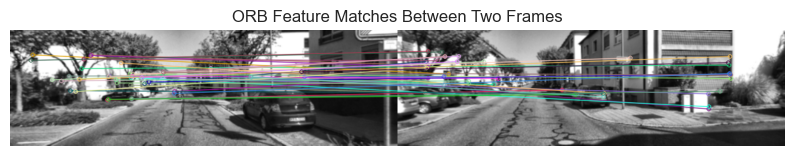

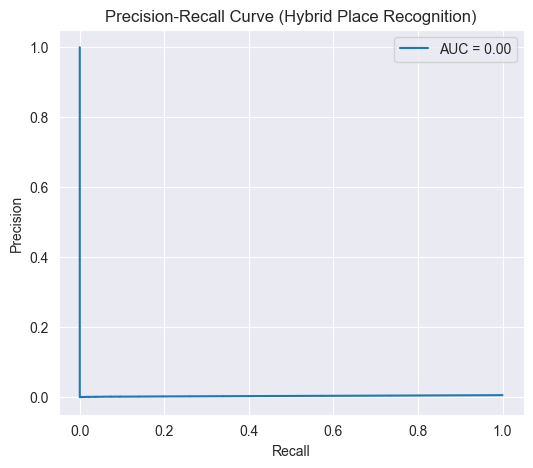

In [27]:
# -----------------------------------
# 7. Compute similarity matrix
# -----------------------------------
def compute_similarity(features):
    n = len(features)
    sim = np.zeros((n, n))
    for i in tqdm(range(n), desc="Computing similarity"):
        for j in range(i+1, n):
            sim_score = np.dot(features[i], features[j])  # cosine similarity
            sim[i, j] = sim[j, i] = sim_score
    return sim

# -----------------------------------
# 8. Evaluate precision-recall using ground truth
# -----------------------------------
def evaluate(similarity, poses, threshold_dist=10.0):
    y_true, y_scores = [], []
    n = len(similarity)
    for i in range(n):
        for j in range(i+20, n):  # skip nearby frames
            y_scores.append(similarity[i, j])
            y_true.append(1 if is_revisit(i, j, poses, threshold_dist) else 0)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auc_score = auc(recall, precision)
    return precision, recall, auc_score

# -----------------------------------
# 9. Visualization
# -----------------------------------
def visualize_matches(img1, img2, kp1, kp2, des1, des2):
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)
    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:40], None, flags=2)
    plt.figure(figsize=(10,5))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title("ORB Feature Matches Between Two Frames")
    plt.axis("off")
    plt.show()

# -----------------------------------
# MAIN PIPELINE
# -----------------------------------
if __name__ == "__main__":
    print("📂 Loading images...")
    images, names = load_images(KITTI_PATH, N_IMAGES)

    print("🧼 Preprocessing images...")
    preprocessed = preprocess_images(images)

    print("🔍 Extracting features...")
    kp_all, des_all = extract_orb_features(preprocessed)
    cnn_feats = extract_cnn_features(preprocessed)
    hybrid_feats = combine_features(cnn_feats, des_all)

    print("📡 Loading ground-truth poses...")
    poses = load_poses(POSE_FILE, N_IMAGES)

    print("📊 Computing similarity...")
    similarity = compute_similarity(hybrid_feats)

    print("🧪 Evaluating system performance...")
    precision, recall, auc_score = evaluate(similarity, poses, threshold_dist=10.0)
    print(f"\n✅ AUC (Precision-Recall): {auc_score*100:.2f}%")

    # Visualization example
    idx1, idx2 = 0, 100
    visualize_matches(preprocessed[idx1], preprocessed[idx2], kp_all[idx1], kp_all[idx2], des_all[idx1], des_all[idx2])

    # Precision-Recall Curve
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"AUC = {auc_score:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (Hybrid Place Recognition)")
    plt.legend()
    plt.grid(True)
    plt.show()